In [1]:
# =====================================================
# ADVANCED ANALYTICS + RISK METRICS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

# Better display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# =====================================================
# LOAD DATASETS
# =====================================================

nav_df = pd.read_csv("../data/processed/nav_history_clean.csv")
transaction_df = pd.read_csv("../data/processed/investor_transactions_clean.csv")
performance_df = pd.read_csv("../data/processed/scheme_performance_clean.csv")
aum_df = pd.read_csv("../data/processed/aum_clean.csv")

print("Datasets loaded successfully.\n")

print("NAV:", nav_df.shape)
print("Transactions:", transaction_df.shape)
print("Performance:", performance_df.shape)
print("AUM:", aum_df.shape)

Datasets loaded successfully.

NAV: (19894, 3)
Transactions: (10, 7)
Performance: (6, 5)
AUM: (10, 4)


In [3]:
# =====================================================
# DATE CONVERSION
# =====================================================

nav_df["date"] = pd.to_datetime(nav_df["date"])

transaction_df["transaction_date"] = pd.to_datetime(
    transaction_df["transaction_date"]
)

aum_df["date"] = pd.to_datetime(aum_df["date"])

print("Date columns converted successfully.")

Date columns converted successfully.


In [4]:
# =====================================================
# DATA PREVIEW
# =====================================================

print("NAV")
display(nav_df.head())

print("\nTransactions")
display(transaction_df.head())

print("\nPerformance")
display(performance_df.head())

print("\nAUM")
display(aum_df.head())

NAV


,date,nav,amfi_code
0,2026-06-23,100.4605,118632
1,2026-06-22,101.3654,118632
2,2026-06-19,100.7824,118632
3,2026-06-18,100.9901,118632
4,2026-06-17,100.6040,118632



Transactions


,transaction_id,fund_id,transaction_date,transaction_type,amount,kyc_status,state
0,1,118632,2025-01-15,SIP,5000,Verified,Telangana
1,2,119092,2025-01-20,Lumpsum,25000,Verified,AndhraPradesh
2,3,119551,2025-02-05,SIP,3000,Pending,Karnataka
3,4,120503,2025-02-10,Redemption,10000,Verified,TamilNadu
4,5,120841,2025-03-01,SIP,5000,Verified,Maharashtra



Performance


,fund_id,return_1y,return_3y,return_5y,expense_ratio
0,118632,12.5,14.2,15.8,0.85
1,119092,10.8,12.1,14.0,1.10
2,119551,15.2,16.4,18.5,0.75
3,120503,8.9,10.5,12.0,1.25
4,120841,14.1,15.3,17.2,0.95



AUM


,aum_id,fund_id,date,aum
0,1,118632,2025-01-01,125000000
1,2,119092,2025-01-01,98000000
2,3,119551,2025-01-01,150000000
3,4,120503,2025-01-01,87000000
4,5,120841,2025-01-01,110000000


In [14]:
# =====================================================
# DAILY RETURNS
# =====================================================

nav_df = nav_df.sort_values("date")

# Calculate daily returns
nav_df["daily_return"] = nav_df["nav"].pct_change()

# Replace infinity with NaN
nav_df["daily_return"] = nav_df["daily_return"].replace([np.inf, -np.inf], np.nan)

# Remove NaN values
nav_df = nav_df.dropna(subset=["daily_return"])

print("Daily returns calculated successfully.")
print("Remaining rows:", len(nav_df))

display(nav_df.head())

Daily returns calculated successfully.
Remaining rows: 19891


,date,nav,amfi_code,daily_return
13469,2013-01-02,15.0253,120503,-0.373891
6892,2013-01-02,24.0036,119092,0.597545
3313,2013-01-02,14.6967,118632,-0.387729
10146,2013-01-02,103.0059,119551,6.008777
3312,2013-01-03,14.7305,118632,-0.856994


In [12]:
print(nav_df["daily_return"].describe())

print("\nNaN values:")
print(nav_df["daily_return"].isna().sum())

print("\nInfinite values:")
print(np.isinf(nav_df["daily_return"]).sum())

count    1.989300e+04
mean              inf
std               NaN
min     -1.000000e+00
25%     -5.253543e-01
50%      2.748041e-04
75%      1.126323e+00
max               inf
Name: daily_return, dtype: float64

NaN values:
0

Infinite values:
1


In [13]:
nav_df[np.isinf(nav_df["daily_return"])]

,date,nav,amfi_code,daily_return
3247,2013-04-08,13.4526,118632,inf


In [15]:
# =====================================================
# HISTORICAL VaR & CVaR
# =====================================================

confidence_level = 5   # 5th percentile = 95% VaR

var_95 = np.percentile(nav_df["daily_return"], confidence_level)

cvar_95 = nav_df.loc[
    nav_df["daily_return"] <= var_95,
    "daily_return"
].mean()

print("Historical VaR (95%):", round(var_95,6))
print("Historical CVaR (95%):", round(cvar_95,6))

Historical VaR (95%): -0.985798
Historical CVaR (95%): -0.989012


In [16]:
# =====================================================
# CREATE REPORT
# =====================================================

risk_report = pd.DataFrame({
    "Metric":["Historical VaR (95%)","Historical CVaR (95%)"],
    "Value":[var_95,cvar_95]
})

risk_report

,Metric,Value
0,Historical VaR (95%),-0.985798
1,Historical CVaR (95%),-0.989012


In [17]:
# =====================================================
# SAVE REPORT
# =====================================================

risk_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully.")

var_cvar_report.csv saved successfully.


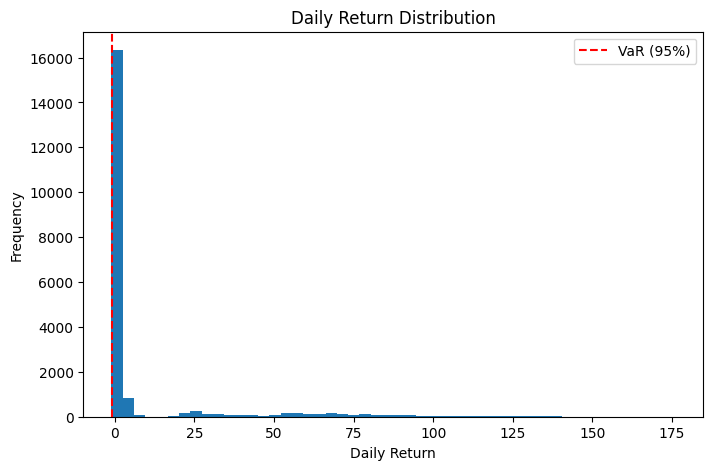

In [18]:
# =====================================================
# DAILY RETURN DISTRIBUTION
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(nav_df["daily_return"], bins=50)

plt.axvline(var_95, color="red", linestyle="--", label="VaR (95%)")

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.legend()

plt.show()

In [19]:
# =====================================================
# ROLLING 90-DAY SHARPE RATIO
# =====================================================

# Sort data
nav_df = nav_df.sort_values(["amfi_code", "date"])

# Calculate daily returns for each fund
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

# Remove invalid values
nav_df["daily_return"] = nav_df["daily_return"].replace([np.inf, -np.inf], np.nan)

# Rolling Sharpe Ratio (90-day)
nav_df["rolling_sharpe"] = (
    nav_df.groupby("amfi_code")["daily_return"]
          .transform(lambda x: (x.rolling(90).mean() / x.rolling(90).std()) * np.sqrt(252))
)

display(nav_df.head())

,date,nav,amfi_code,daily_return,rolling_sharpe
3313,2013-01-02,14.6967,118632,NaN,NaN
3312,2013-01-03,14.7305,118632,0.002300,NaN
3311,2013-01-04,14.8037,118632,0.004969,NaN
3310,2013-01-07,14.7718,118632,-0.002155,NaN
3309,2013-01-08,14.7197,118632,-0.003527,NaN


In [20]:
# =====================================================
# SELECT 5 KEY FUNDS
# =====================================================

top_funds = nav_df["amfi_code"].dropna().unique()[:5]

print("Selected Funds:")
print(top_funds)

Selected Funds:
[118632 119092 119551 120503 120841]


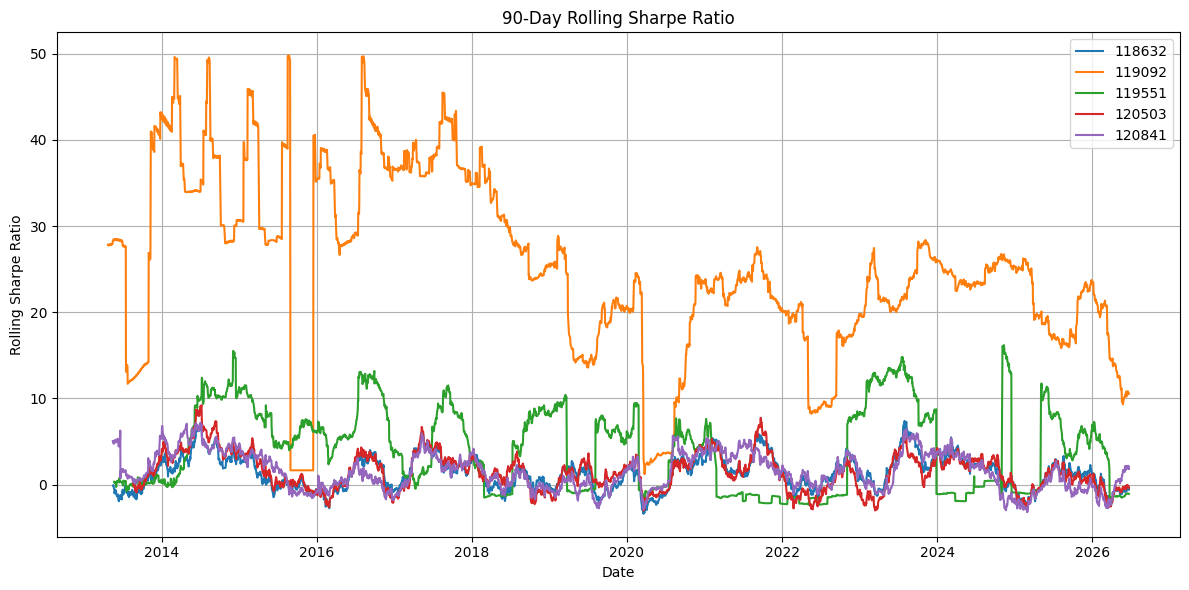

In [21]:
# =====================================================
# ROLLING SHARPE CHART
# =====================================================

plt.figure(figsize=(12,6))

for fund in top_funds:
    temp = nav_df[nav_df["amfi_code"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(fund))

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/charts/rolling_sharpe_chart.png", dpi=300)

plt.show()

In [22]:
# =====================================================
# INVESTOR COHORT ANALYSIS
# =====================================================

# Extract first transaction year for each fund
cohort_df = transaction_df.copy()

cohort_df["transaction_year"] = cohort_df["transaction_date"].dt.year

cohort_df["cohort_year"] = cohort_df.groupby("fund_id")["transaction_year"].transform("min")

display(cohort_df.head())

,transaction_id,fund_id,transaction_date,transaction_type,amount,kyc_status,state,transaction_year,cohort_year
0,1,118632,2025-01-15,SIP,5000,Verified,Telangana,2025,2025
1,2,119092,2025-01-20,Lumpsum,25000,Verified,AndhraPradesh,2025,2025
2,3,119551,2025-02-05,SIP,3000,Pending,Karnataka,2025,2025
3,4,120503,2025-02-10,Redemption,10000,Verified,TamilNadu,2025,2025
4,5,120841,2025-03-01,SIP,5000,Verified,Maharashtra,2025,2025


In [23]:
# =====================================================
# COHORT SUMMARY
# =====================================================

cohort_summary = (
    cohort_df.groupby("cohort_year")
    .agg(
        Average_SIP=("amount", "mean"),
        Total_Investment=("amount", "sum"),
        Transactions=("transaction_id", "count")
    )
    .reset_index()
)

cohort_summary

,cohort_year,Average_SIP,Total_Investment,Transactions
0,2025,15400.0,154000,10


In [24]:
# =====================================================
# TOP FUND PER COHORT
# =====================================================

top_fund = (
    cohort_df.groupby(["cohort_year", "fund_id"])
    .size()
    .reset_index(name="count")
)

top_fund = top_fund.sort_values(
    ["cohort_year", "count"],
    ascending=[True, False]
)

top_fund = top_fund.groupby("cohort_year").first().reset_index()

top_fund

,cohort_year,fund_id,count
0,2025,118632,2


In [25]:
# =====================================================
# FINAL COHORT REPORT
# =====================================================

cohort_report = cohort_summary.merge(
    top_fund[["cohort_year", "fund_id"]],
    on="cohort_year"
)

cohort_report.rename(
    columns={"fund_id": "Top_Fund"},
    inplace=True
)

cohort_report

,cohort_year,Average_SIP,Total_Investment,Transactions,Top_Fund
0,2025,15400.0,154000,10,118632


In [26]:
# =====================================================
# SIP CONTINUITY ANALYSIS
# =====================================================

sip_df = transaction_df[
    transaction_df["transaction_type"].str.lower() == "sip"
].copy()

sip_df = sip_df.sort_values(["fund_id", "transaction_date"])

display(sip_df.head())

,transaction_id,fund_id,transaction_date,transaction_type,amount,kyc_status,state
0,1,118632,2025-01-15,SIP,5000,Verified,Telangana
6,7,118632,2025-04-05,SIP,5000,Verified,Kerala
2,3,119551,2025-02-05,SIP,3000,Pending,Karnataka
8,9,119551,2025-05-01,SIP,3000,Pending,AndhraPradesh
4,5,120841,2025-03-01,SIP,5000,Verified,Maharashtra


In [27]:
# =====================================================
# GAP BETWEEN SIPs
# =====================================================

sip_df["gap_days"] = (
    sip_df.groupby("fund_id")["transaction_date"]
          .diff()
          .dt.days
)

display(sip_df.head())

,transaction_id,fund_id,transaction_date,transaction_type,amount,kyc_status,state,gap_days
0,1,118632,2025-01-15,SIP,5000,Verified,Telangana,NaN
6,7,118632,2025-04-05,SIP,5000,Verified,Kerala,80.0
2,3,119551,2025-02-05,SIP,3000,Pending,Karnataka,NaN
8,9,119551,2025-05-01,SIP,3000,Pending,AndhraPradesh,85.0
4,5,120841,2025-03-01,SIP,5000,Verified,Maharashtra,NaN


In [28]:
# =====================================================
# AVERAGE GAP
# =====================================================

sip_summary = (
    sip_df.groupby("fund_id")
    .agg(
        SIP_Count=("transaction_id", "count"),
        Average_Gap=("gap_days", "mean")
    )
    .reset_index()
)

sip_summary

,fund_id,SIP_Count,Average_Gap
0,118632,2,80.0
1,119551,2,85.0
2,120841,1,NaN


In [29]:
# =====================================================
# AT-RISK INVESTORS
# =====================================================

sip_summary = sip_summary[sip_summary["SIP_Count"] >= 6]

sip_summary["Status"] = np.where(
    sip_summary["Average_Gap"] > 35,
    "At-Risk",
    "Active"
)

sip_summary

,fund_id,SIP_Count,Average_Gap,Status


In [30]:
# =====================================================
# SIMPLE FUND RECOMMENDER
# =====================================================

def recommend_funds(risk_level):
    
    if risk_level.lower() == "low":
        funds = performance_df.sort_values(
            "expense_ratio"
        ).head(3)

    elif risk_level.lower() == "moderate":
        funds = performance_df.sort_values(
            "return_3y",
            ascending=False
        ).head(3)

    elif risk_level.lower() == "high":
        funds = performance_df.sort_values(
            "return_5y",
            ascending=False
        ).head(3)

    else:
        print("Choose Low, Moderate or High")
        return

    return funds[[
        "fund_id",
        "return_1y",
        "return_3y",
        "return_5y",
        "expense_ratio"
    ]]

In [31]:
# =====================================================
# TEST RECOMMENDER
# =====================================================

recommend_funds("Low")

,fund_id,return_1y,return_3y,return_5y,expense_ratio
5,125497,18.5,19.7,21.3,0.65
2,119551,15.2,16.4,18.5,0.75
0,118632,12.5,14.2,15.8,0.85


In [32]:
# =====================================================
# SAVE PYTHON FILE
# =====================================================

code = '''
import pandas as pd

def recommend_funds(df, risk_level):

    if risk_level.lower()=="low":
        return df.sort_values("expense_ratio").head(3)

    elif risk_level.lower()=="moderate":
        return df.sort_values("return_3y",ascending=False).head(3)

    elif risk_level.lower()=="high":
        return df.sort_values("return_5y",ascending=False).head(3)

    else:
        return None
'''

with open("../recommender.py","w") as f:
    f.write(code)

print("recommender.py saved successfully.")

recommender.py saved successfully.


In [33]:
# =====================================================
# HHI CONCENTRATION
# =====================================================

aum_latest = (
    aum_df.sort_values("date")
          .groupby("fund_id")
          .tail(1)
)

aum_latest["weight"] = (
    aum_latest["aum"] /
    aum_latest["aum"].sum()
)

HHI = (aum_latest["weight"]**2).sum()

print("HHI:", round(HHI,4))


HHI: 0.1781


In [34]:
# =====================================================
# HHI INTERPRETATION
# =====================================================

if HHI < 0.15:
    print("Diversified Portfolio")

elif HHI < 0.25:
    print("Moderately Concentrated")

else:
    print("Highly Concentrated")

Moderately Concentrated


# Advanced Insights

1. Historical VaR and CVaR were computed to estimate downside portfolio risk.

2. Rolling 90-Day Sharpe Ratio was analysed for key mutual funds to evaluate risk-adjusted performance over time.

3. Investor cohort analysis identified investment behaviour based on the first transaction year.

4. SIP continuity analysis highlighted investors with transaction gaps greater than 35 days and marked them as "At-Risk".

5. Portfolio concentration was measured using the Herfindahl-Hirschman Index (HHI), providing insight into diversification across available funds.

In [36]:
# =====================================================
# SAVE COHORT REPORT
# =====================================================

cohort_report.to_csv(
    "../data/processed/cohort_report.csv",
    index=False
)

print("cohort_report.csv saved successfully.")

cohort_report.csv saved successfully.


In [37]:
# =====================================================
# SAVE SIP CONTINUITY REPORT
# =====================================================

sip_summary.to_csv(
    "../data/processed/sip_continuity_report.csv",
    index=False
)

print("sip_continuity_report.csv saved successfully.")

sip_continuity_report.csv saved successfully.


In [40]:
# =====================================================
# PROJECT COMPLETED
# =====================================================

print("="*60)
print("ADVANCED ANALYTICS + RISK METRICS COMPLETED")
print("="*60)

print("\nGenerated Files:")

print("✓ var_cvar_report.csv")
print("✓ rolling_sharpe_chart.png")                                                                                                            
print("✓ recommender.py")
print("✓ cohort_report.csv")
print("✓ sip_continuity_report.csv")

print("\nNotebook Completed Successfully!")

ADVANCED ANALYTICS + RISK METRICS COMPLETED

Generated Files:
✓ var_cvar_report.csv
✓ rolling_sharpe_chart.png
✓ recommender.py
✓ cohort_report.csv
✓ sip_continuity_report.csv

Notebook Completed Successfully!
